In [1]:
import os
import sys
import json
import argparse

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import nibabel as nib

from glob import glob
from nilearn import plotting
from nilearn import datasets

from nilearn.glm.second_level import SecondLevelModel
from nilearn.glm.second_level import make_second_level_design_matrix
from nilearn.image import smooth_img, new_img_like

In [2]:
from nilearn.image import threshold_img
from nilearn.glm import threshold_stats_img

from nilearn import surface
from nilearn import datasets
fsaverage = datasets.fetch_surf_fsaverage()
mni152_template = datasets.load_mni152_template(resolution=1)


In [4]:
task_label = 'badaga'

bidsroot = os.path.join('/bgfs/bchandrasekaran/krs228/data/',
                        'SSP/data_bids/')
deriv_dir = os.path.join(bidsroot, 'derivatives')
nilearn_dir = os.path.join(bidsroot, 'derivatives', 'nilearn')

## Second-level analyses

Based on [nilearn documentation](https://nilearn.github.io/stable/auto_examples/05_glm_second_level/plot_thresholding.html#statistical-testing-of-a-second-level-analysis)

### Build the group-level design matrix

#### Read the `participants.tsv` file from the BIDS root directory

In [19]:
participants_fpath = os.path.join(bidsroot, 'participants.tsv')
participants_df = pd.read_csv(participants_fpath, sep='\t')

# subjects to ignore (not fully processed, etc.)
ignore_subs = ['sub-SSP001', 'sub-SSP002',
               'sub-SSP005', 'sub-SSP012',
               'sub-SSP013', 'sub-SSP014',
               'sub-SSP040', 
               'sub-SSP069', 'sub-SSP072',
               'sub-SSP077', 'sub-SSP078',
               'sub-SSP041', 'sub-SSP054', 'sub-SSP060', 
               
               ]
participants_df.drop(participants_df[participants_df.participant_id.isin(ignore_subs)].index, inplace=True)

# re-sort by participant ID
participants_df.sort_values(by=['participant_id'], ignore_index=True, inplace=True)

In [20]:
participants_fpath

'/bgfs/bchandrasekaran/krs228/data/SSP/data_bids/participants.tsv'

In [21]:
print(participants_df)

   participant_id  age sex    group
0      sub-SSP009    9   M  control
1      sub-SSP011   11   M  control
2      sub-SSP017   11   M  control
3      sub-SSP018    8   F      CWS
4      sub-SSP020   13   F      CWS
5      sub-SSP028   10   M  control
6      sub-SSP032   12   M  control
7      sub-SSP033    7   F  control
8      sub-SSP034    9   F  control
9      sub-SSP036   11   M  control
10     sub-SSP038    9   M  control
11     sub-SSP039   12   M  control
12     sub-SSP045   10   M      CWS
13     sub-SSP046    0   0      CWS
14     sub-SSP051    8   F  control


In [22]:
# create group-specific lists of subject IDs
sub_list_cwns = list(participants_df.participant_id[participants_df.group=='control'])#'CWNS'])
sub_list_cws = list(participants_df.participant_id[participants_df.group=='CWS'])

In [23]:
sub_list_cwns

['sub-SSP009',
 'sub-SSP011',
 'sub-SSP017',
 'sub-SSP028',
 'sub-SSP032',
 'sub-SSP033',
 'sub-SSP034',
 'sub-SSP036',
 'sub-SSP038',
 'sub-SSP039',
 'sub-SSP051']

#### Create design matrixes

In [24]:
# get participant IDs and their group labels
subjects_label = list(participants_df.participant_id)
groups_label = list(participants_df.group)

# make new dataframe from the group labels
design_mat_groupdiff = pd.DataFrame({'CWS': groups_label,
                                     'CWNS': groups_label,
                                    }
                                   )
# convert to 1s and 0s for each group as appropriate
design_mat_groupdiff['CWS'].loc[design_mat_groupdiff['CWS'] == 'CWS'] = 1
design_mat_groupdiff['CWS'].loc[design_mat_groupdiff['CWS'] == 'control'] = 0
design_mat_groupdiff['CWNS'].loc[design_mat_groupdiff['CWNS'] == 'CWS'] = 0
design_mat_groupdiff['CWNS'].loc[design_mat_groupdiff['CWNS'] == 'control'] = 1
design_mat_groupdiff = design_mat_groupdiff.astype('int')
print(design_mat_groupdiff)

    CWS  CWNS
0     0     1
1     0     1
2     0     1
3     1     0
4     1     0
5     0     1
6     0     1
7     0     1
8     0     1
9     0     1
10    0     1
11    0     1
12    1     0
13    1     0
14    0     1


/scratch/slurm-5135059/ipykernel_20170/753025560.py:11: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  design_mat_groupdiff['CWS'].loc[design_mat_groupdiff['CWS'] == 'CWS'] = 1
/scratch/slurm-5135059/ipykernel_20170/753025560.py:12: FutureWar

In [25]:
print(subjects_label)

['sub-SSP009', 'sub-SSP011', 'sub-SSP017', 'sub-SSP018', 'sub-SSP020', 'sub-SSP028', 'sub-SSP032', 'sub-SSP033', 'sub-SSP034', 'sub-SSP036', 'sub-SSP038', 'sub-SSP039', 'sub-SSP045', 'sub-SSP046', 'sub-SSP051']


# Run-all

### Get files

In [ ]:
fwhm = 0.00
searchrad = 5
model_label = 'run-specific' # 'run-all'
space_label = 'MNI152NLin2009cAsym'
l1_dir = os.path.join(bidsroot, 'derivatives', 
                      'nilearn', f'rsa-searchlight_run-specific')
l2_dir = os.path.join(bidsroot, 'derivatives', 
                      'nilearn', f'group_rsa-searchlight_run-specific')
os.makedirs(l2_dir, exist_ok=True)

In [ ]:
l2_dir

In [ ]:
model_list = ['snr', 'syllable']

model_label = model_list[0]

In [ ]:
l1_fnames_groupdiff = [sorted(glob(l1_dir+f'/{sub_id}_space-{space_label}/{search_label}/' +
                                   '%s_fwhm-%.02f_searchvox-%d_rsa-searchlight_model-%s.nii.gz'%(sub_id, fwhm, searchrad, model_label)))[0] for sub_id in subjects_label]

In [ ]:
l1_fnames_groupdiff

## WIP: fisher's r-to-z transformation

### loop through images and transform

In [ ]:
diff_img_list = []

for sx, sub_sl_fpath in enumerate(l1_fnames_groupdiff):
    
    sub_sl_img = nib.load(sub_sl_fpath)
    sub_sl_data = sub_sl_img.get_fdata()

    # fisher transform r-to-z
    diff_data = np.arctanh(sub_sl_data)

    diff_img = new_img_like(sub_sl_img, diff_data)

    diff_img_list.append(diff_img)

### Non-Mandarin-speaking participants group RSA

In [ ]:
#second_level_model = SecondLevelModel().fit(smoothed_l1_fnames_groupdiff, design_matrix=design_mat_groupdiff)
second_level_model = SecondLevelModel().fit(diff_img_list, design_matrix=design_mat_groupdiff)

z_map = second_level_model.compute_contrast(second_level_contrast=[0,1,], output_type='z_score')

In [ ]:
group_label = 'NMan'
out_fname = 'group-{}_{}_model-{}_map-zstat.nii.gz'.format(group_label, search_label, model_label)
out_fpath = os.path.join(l2_dir, out_fname)
nib.save(z_map, out_fpath)

In [ ]:
alpha = 0.001
cthresh = 10
cluster_correct =  'fdr' # None

thresholded_map, zthresh = threshold_stats_img(
                            z_map,
                            alpha=alpha,
                            height_control=cluster_correct,
                            cluster_threshold=cthresh,
                            two_sided=False,
                        )

In [ ]:
plotting.plot_stat_map(
    thresholded_map, #cut_coords=[17,12,5], 
    threshold=zthresh,
    title='%s thresholded z map, z > %.02f, clusters > %d voxels'%(group_label, threshold, cthresh))

In [ ]:
plotting.view_img(thresholded_map,
                  threshold=zthresh,
                  symmetric_cmap=True)

In [ ]:
plotting.plot_img_on_surf(thresholded_map,
                          surf_mesh='fsaverage', # comment out for faster default (fsaverage5)
                          views=['lateral', 'medial'],
                          hemispheres=['left', 'right'],
                          inflate=True,
                          threshold=zthresh,
                          #cmap='Reds',
                          colorbar=True,
                          title='%s thresholded z map, z > %.02f, clusters > %d voxels'%(group_label, threshold, cthresh))
plotting.show()

In [ ]:
title = ('Non-Mandarin-speaking group (n=%d) RSA-%s \n'
         'FDR-corrected p < %.03f, clusters > %d voxels'%(len(sub_list_nman), model_label, alpha, cthresh))

#fig = plt.figure(constrained_layout=True, figsize=(8,4), dpi=500)
#subfigs = fig.subfigures(nrows=3, ncols=1)
fig, axes = plt.subplots(3, 1, figsize=(6,3), dpi=500)
fig.suptitle(title, fontsize='medium')

fig_fpath = os.path.join(l2_dir, 
                         f'group-{group_label}_rsa-searchlight_model-{model_label}_searchrad-{searchrad}_fwhm-{fwhm}_map-zstat_slice.png')

plotting.plot_stat_map(thresholded_map, 
                       bg_img=mni152_template, 
                       black_bg=False,
                       display_mode='x',
                       cut_coords=[-60, -45, -30, -15, 0, 15, 30, 45, 60],
                       colorbar=False,
                       annotate=False,
                       #title=title,
                       figure=fig, 
                       axes=axes[0])
plotting.plot_stat_map(thresholded_map, 
                       bg_img=mni152_template, 
                       black_bg=False,
                       display_mode='y',
                       cut_coords=[-100, -80, -60, -40, -20, 0, 20, 40, 60],
                       colorbar=False,
                       annotate=False,
                       #title=title,
                       figure=fig, 
                       axes=axes[1])
plotting.plot_stat_map(thresholded_map, 
                       bg_img=mni152_template, 
                       black_bg=False,
                       display_mode='z',
                       cut_coords=[-50, -35, -20, -5, 10, 25, 40, 55, 70],
                       colorbar=False,
                       annotate=False,
                       #title=title,
                       #figure=fig, 
                       axes=axes[2])

fig.savefig(fig_fpath)
print('file saved to ', fig_fpath)

### Group differences in RSA searchlight

In [ ]:
#second_level_model = SecondLevelModel().fit(smoothed_l1_fnames_groupdiff, design_matrix=design_mat_groupdiff)
second_level_model = SecondLevelModel().fit(diff_img_list, design_matrix=design_mat_groupdiff)
z_map_diff = second_level_model.compute_contrast(second_level_contrast=[1, -1,], output_type='z_score')

In [ ]:
'''
for model_label in [model_label]: #model_list:
    print(model_label)
    l1_fnames_groupdiff = [sorted(glob(l1_dir+'/%s_space-%s/%s/'%(sub_id, space_label, search_label) +
                                   '%s_rsa-searchlight_model-%s.nii.gz'%(sub_id, model_label)))[0] for sub_id in subjects_label]
    
    diff_img_list = []
    for sx, sub_sl_fpath in enumerate(l1_fnames_groupdiff):

        sub_sl_img = nib.load(sub_sl_fpath)
        sub_sl_data = sub_sl_img.get_fdata()

        # fisher transform r-to-z
        diff_data = np.arctanh(sub_sl_data)
        diff_img = new_img_like(sub_sl_img, diff_data)
        diff_img_list.append(diff_img)

    second_level_model = SecondLevelModel().fit(diff_img_list, design_matrix=design_mat_groupdiff)
    z_map_diff = second_level_model.compute_contrast(second_level_contrast=[1, -1,], output_type='z_score')

    group_label = 'diff-Mand-gt-NMan'
    out_fname = 'group-{}_{}_model-{}_map-zstat.nii.gz'.format(group_label, search_label, model_label) 
    out_fpath = os.path.join(l2_dir, out_fname)
    nib.save(z_map_diff, out_fpath)
'''

In [ ]:
threshold = 2.58
cthresh = 10
thresh_diff_map = threshold_img(
                                z_map_diff,
                                threshold=threshold,
                                cluster_threshold=cthresh,
                                two_sided=True,
                            )

In [ ]:
plotting.plot_stat_map(
    thresh_diff_map, 
    title='%s thresholded z map, z > %.02f, clusters > %d voxels'%(group_label, threshold, cthresh))

In [ ]:
plotting.view_img(thresh_diff_map,
                  threshold=threshold,
                  symmetric_cmap=True)

In [ ]:
plotting.plot_img_on_surf(thresh_diff_map,
                          #surf_mesh='fsaverage', # comment out for faster default (fsaverage5)
                          views=['lateral', 'medial'],
                          hemispheres=['left', 'right'],
                          inflate=True,
                          threshold=threshold,
                          #cmap='Reds',
                          colorbar=True,
                          title='%s thresholded z map, z > %.02f, clusters > %d voxels'%(group_label, threshold, cthresh))
plotting.show()

## loop over all images and save

In [ ]:
for group_label in ['Mand', 'NMan', 'diff-Mand-gt-NMan']: #
    for model_label in model_list:
        img_fname = 'group-{}_rsa-searchlight_model-{}_map-zstat.nii.gz'.format(group_label, model_label)
        img_fpath = os.path.join(l2_dir, img_fname)

        fig_fpath = os.path.join('level-2_out', 
                                 'group-{}_rsa-searchlight_model-{}_map-zstat.png'.format(group_label, 
                                                                                          model_label))
        title='group-%s model-%s\nz > %.02f – clusters > %d voxels'%(group_label, model_label, threshold, cthresh)
        threshold = 2.58
        cthresh = 10
        thresholded_map = threshold_img(
                                        img_fpath,
                                        threshold=threshold,
                                        cluster_threshold=cthresh,
                                        two_sided=True,
                                    )
        #fig, ax = plt.subplots(subplot_kw={"projection": "3d"}, figsize=(5,4), dpi=500)
        fig, ax = plotting.plot_img_on_surf(thresholded_map,
                                  surf_mesh='fsaverage',
                                  views=['lateral', 'medial'],
                                  hemispheres=['left', 'right'],
                                  inflate=True,
                                  threshold=threshold,
                                  colorbar=True,
                                  title=title,
                                  #kwargs={'figure':fig, 'axes':ax}
                                 )
        fig.savefig(fig_fpath)
        print('file saved to ', fig_fpath)

In [ ]:
threshold = 2.58
cthresh = 10
    
for group_label in ['Mand', 'NMan', 'diff-Mand-gt-NMan']: # 'Mand', 'NMan', 'diff-Mand-gt-NMan'
    for model_label in model_list:
        title='group-%s model-%s \n z > %.02f – clusters > %d voxels'%(group_label, model_label, threshold, cthresh)
        
        #fig = plt.figure(constrained_layout=True, figsize=(8,4), dpi=500)
        #subfigs = fig.subfigures(nrows=3, ncols=1)
        fig, axes = plt.subplots(3, 1, figsize=(6,3), dpi=500)
        fig.suptitle(title)
        
        img_fname = 'group-{}_rsa-searchlight_model-{}_map-zstat.nii.gz'.format(group_label, model_label)
        img_fpath = os.path.join(l2_dir, img_fname)

        fig_fpath = os.path.join('level-2_out', 
                                 'group-{}_rsa-searchlight_model-{}_map-zstat_slice.png'.format(group_label, 
                                                                                          model_label))
        thresholded_map = threshold_img(
                                        img_fpath,
                                        threshold=threshold,
                                        cluster_threshold=cthresh,
                                        two_sided=True,
                                    )

        plotting.plot_stat_map(thresholded_map, 
                               bg_img=mni152_template, 
                               black_bg=False,
                               display_mode='x',
                               cut_coords=[-60, -45, -30, -15, 0, 15, 30, 45, 60],
                               colorbar=False,
                               annotate=False,
                               #title=title,
                               figure=fig, 
                               axes=axes[0])
        plotting.plot_stat_map(thresholded_map, 
                               bg_img=mni152_template, 
                               black_bg=False,
                               display_mode='y',
                               cut_coords=[-100, -80, -60, -40, -20, 0, 20, 40, 60],
                               colorbar=False,
                               annotate=False,
                               #title=title,
                               figure=fig, 
                               axes=axes[1])
        plotting.plot_stat_map(thresholded_map, 
                               bg_img=mni152_template, 
                               black_bg=False,
                               display_mode='z',
                               cut_coords=[-50, -35, -20, -5, 10, 25, 40, 55, 70],
                               colorbar=False,
                               annotate=False,
                               #title=title,
                               #figure=fig, 
                               axes=axes[2])
        
        fig.savefig(fig_fpath)
        print('file saved to ', fig_fpath)

## All participants

In [ ]:
group_label = 'all'

#second_level_model = SecondLevelModel().fit(smoothed_l1_fnames_groupdiff, design_matrix=design_mat_groupdiff)
second_level_model = SecondLevelModel().fit(diff_img_list, design_matrix=design_mat_groupdiff)
z_map_diff = second_level_model.compute_contrast(second_level_contrast=[1, 1,], output_type='z_score')

In [ ]:
alpha = 0.001
cthresh = 10
cluster_correct = 'fdr'

thresholded_map, zthresh = threshold_stats_img(
                            z_map_diff,
                            alpha=alpha,
                            height_control=cluster_correct,
                            cluster_threshold=cthresh,
                            two_sided=False,
                        )

In [ ]:
plot_title = ('All participants (n=%d)\n'
              'RSA-%s FDR-corrected z map \n'
              'p < %.04g, clusters > %d voxels'%(len(sub_list_mand+sub_list_nman), model_label, alpha, cthresh))

fig, ax = plt.subplots(figsize=(8,3), dpi=300)

plotting.plot_stat_map(
    thresholded_map, 
    threshold=zthresh,
    bg_img=mni152_template,
    black_bg=False,
    cut_coords=[-50, -26, 6],
    #display_mode='mosaic',
    #title=plot_title,
    axes=ax)
fig.suptitle(plot_title, fontsize=10);
print('The %s=%.3g threshold is %.3g' %(cluster_correct, alpha, zthresh))
#fig.savefig(os.path.join(l2_dir,
#                         f'group-{group_label}_mvpc-searchlight_searchmm-{search_radmm}_fwhm-{fwhm:02f}_alpha-{alpha}_correct-{cluster_correct}_cthresh-{cthresh}_map-zstat.png'))

In [ ]:
plotting.view_img(thresholded_map,
                  threshold=zthresh,
                  symmetric_cmap=False,
                  title='p < %.04g, clusters > %d voxels'%(alpha, cthresh))

In [ ]:
title = ('All participants (n=%d) RSA-%s \n'
         'FDR-corrected p < %.04g, clusters > %d voxels'%(len(sub_list_nman+sub_list_mand), model_label, alpha, cthresh))

#fig = plt.figure(constrained_layout=True, figsize=(8,4), dpi=500)
#subfigs = fig.subfigures(nrows=3, ncols=1)
fig, axes = plt.subplots(3, 1, figsize=(6,3), dpi=500)
fig.suptitle(title, fontsize='medium')

fig_fpath = os.path.join(l2_dir, 
                         f'group-{group_label}_rsa-searchlight_model-{model_label}_searchrad-{searchrad}_fwhm-{fwhm}_map-zstat_slice.png')

plotting.plot_stat_map(thresholded_map, 
                       bg_img=mni152_template, 
                       black_bg=False,
                       display_mode='x',
                       cut_coords=[-60, -45, -30, -15, 0, 15, 30, 45, 60],
                       colorbar=False,
                       annotate=False,
                       #title=title,
                       figure=fig, 
                       axes=axes[0])
plotting.plot_stat_map(thresholded_map, 
                       bg_img=mni152_template, 
                       black_bg=False,
                       display_mode='y',
                       cut_coords=[-100, -80, -60, -40, -20, 0, 20, 40, 60],
                       colorbar=False,
                       annotate=False,
                       #title=title,
                       figure=fig, 
                       axes=axes[1])
plotting.plot_stat_map(thresholded_map, 
                       bg_img=mni152_template, 
                       black_bg=False,
                       display_mode='z',
                       cut_coords=[-50, -35, -20, -5, 10, 25, 40, 55, 70],
                       colorbar=False,
                       annotate=False,
                       #title=title,
                       #figure=fig, 
                       axes=axes[2])

fig.savefig(fig_fpath)
print('file saved to ', fig_fpath)

# Per run

### Get files

In [26]:
fwhm = 0.00
searchrad = 5
model_label = 'run-specific' # 'run-all'
space_label = 'MNI152NLin2009cAsym'
l1_dir = os.path.join(bidsroot, 'derivatives', 
                      'nilearn', f'rsa-searchlight_run-specific')
l2_dir = os.path.join(bidsroot, 'derivatives', 
                      'nilearn', f'group_rsa-searchlight_run-specific')
os.makedirs(l2_dir, exist_ok=True)

In [27]:
l2_dir

'/bgfs/bchandrasekaran/krs228/data/SSP/data_bids/derivatives/nilearn/group_rsa-searchlight_run-specific'

In [28]:
model_list = ['snr', 'syllable']

## SNR model

In [ ]:
model_label = model_list[0]

In [29]:
run_num = 1

l1_fnames_groupdiff = [sorted(glob(l1_dir+f'/{sub_id}/run-{run_num}/' +
                                   f'{sub_id}_{run_num}_fwhm-{fwhm:.02f}_searchvox-{searchrad}_rsa-searchlight_contrast-sound_model-{model_label}.nii.gz'))[0] for sub_id in subjects_label]

In [30]:
l1_fnames_groupdiff

['/bgfs/bchandrasekaran/krs228/data/SSP/data_bids/derivatives/nilearn/rsa-searchlight_run-specific/sub-SSP009/run-1/sub-SSP009_1_fwhm-0.00_searchvox-5_rsa-searchlight_contrast-sound_model-snr.nii.gz',
 '/bgfs/bchandrasekaran/krs228/data/SSP/data_bids/derivatives/nilearn/rsa-searchlight_run-specific/sub-SSP011/run-1/sub-SSP011_1_fwhm-0.00_searchvox-5_rsa-searchlight_contrast-sound_model-snr.nii.gz',
 '/bgfs/bchandrasekaran/krs228/data/SSP/data_bids/derivatives/nilearn/rsa-searchlight_run-specific/sub-SSP017/run-1/sub-SSP017_1_fwhm-0.00_searchvox-5_rsa-searchlight_contrast-sound_model-snr.nii.gz',
 '/bgfs/bchandrasekaran/krs228/data/SSP/data_bids/derivatives/nilearn/rsa-searchlight_run-specific/sub-SSP018/run-1/sub-SSP018_1_fwhm-0.00_searchvox-5_rsa-searchlight_contrast-sound_model-snr.nii.gz',
 '/bgfs/bchandrasekaran/krs228/data/SSP/data_bids/derivatives/nilearn/rsa-searchlight_run-specific/sub-SSP020/run-1/sub-SSP020_1_fwhm-0.00_searchvox-5_rsa-searchlight_contrast-sound_model-snr.nii.

### loop through images and transform fisher's r-to-z

In [31]:
diff_img_list = []

for sx, sub_sl_fpath in enumerate(l1_fnames_groupdiff):
    
    sub_sl_img = nib.load(sub_sl_fpath)
    sub_sl_data = sub_sl_img.get_fdata()

    # fisher transform r-to-z
    diff_data = np.arctanh(sub_sl_data)

    diff_img = new_img_like(sub_sl_img, diff_data)

    diff_img_list.append(diff_img)

### CWNS group RSA

In [32]:
#second_level_model = SecondLevelModel().fit(smoothed_l1_fnames_groupdiff, design_matrix=design_mat_groupdiff)
second_level_model = SecondLevelModel().fit(diff_img_list, design_matrix=design_mat_groupdiff)

z_map = second_level_model.compute_contrast(second_level_contrast=[0, 1,], output_type='z_score')

In [35]:
group_label = 'cwns'
out_fname = f'group-{group_label}_model-{model_label}_map-zstat.nii.gz'
out_fpath = os.path.join(l2_dir, out_fname)
nib.save(z_map, out_fpath)

In [36]:
print(out_fpath)

/bgfs/bchandrasekaran/krs228/data/SSP/data_bids/derivatives/nilearn/group_rsa-searchlight_run-specific/group-cwns_model-snr_map-zstat.nii.gz


In [47]:
from nilearn.image import threshold_img
from nilearn.glm import threshold_stats_img
alpha = 0.05
cthresh = 10
cluster_correct = None # 'fdr'

thresholded_map, zthresh = threshold_stats_img(
                            z_map,
                            alpha=alpha,
                            height_control=cluster_correct,
                            cluster_threshold=cthresh,
                            two_sided=True,
                        )

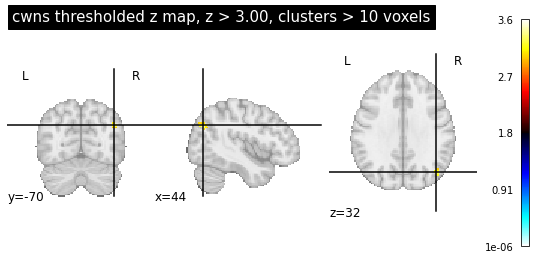

In [49]:
plotting.plot_stat_map(
    thresholded_map, #cut_coords=[17,12,5], 
    #threshold=threshold,
    title='%s thresholded z map, z > %.02f, clusters > %d voxels'%(group_label, zthresh, cthresh))


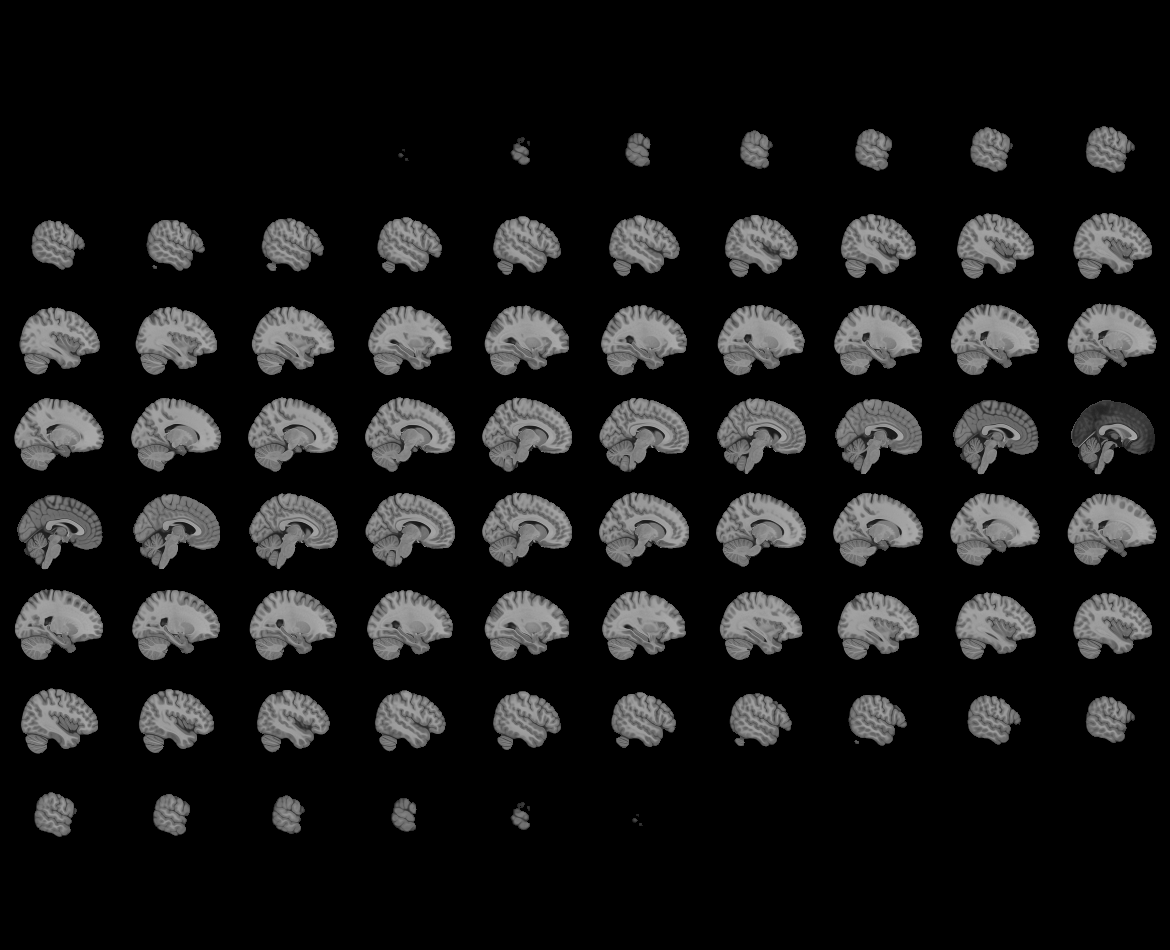
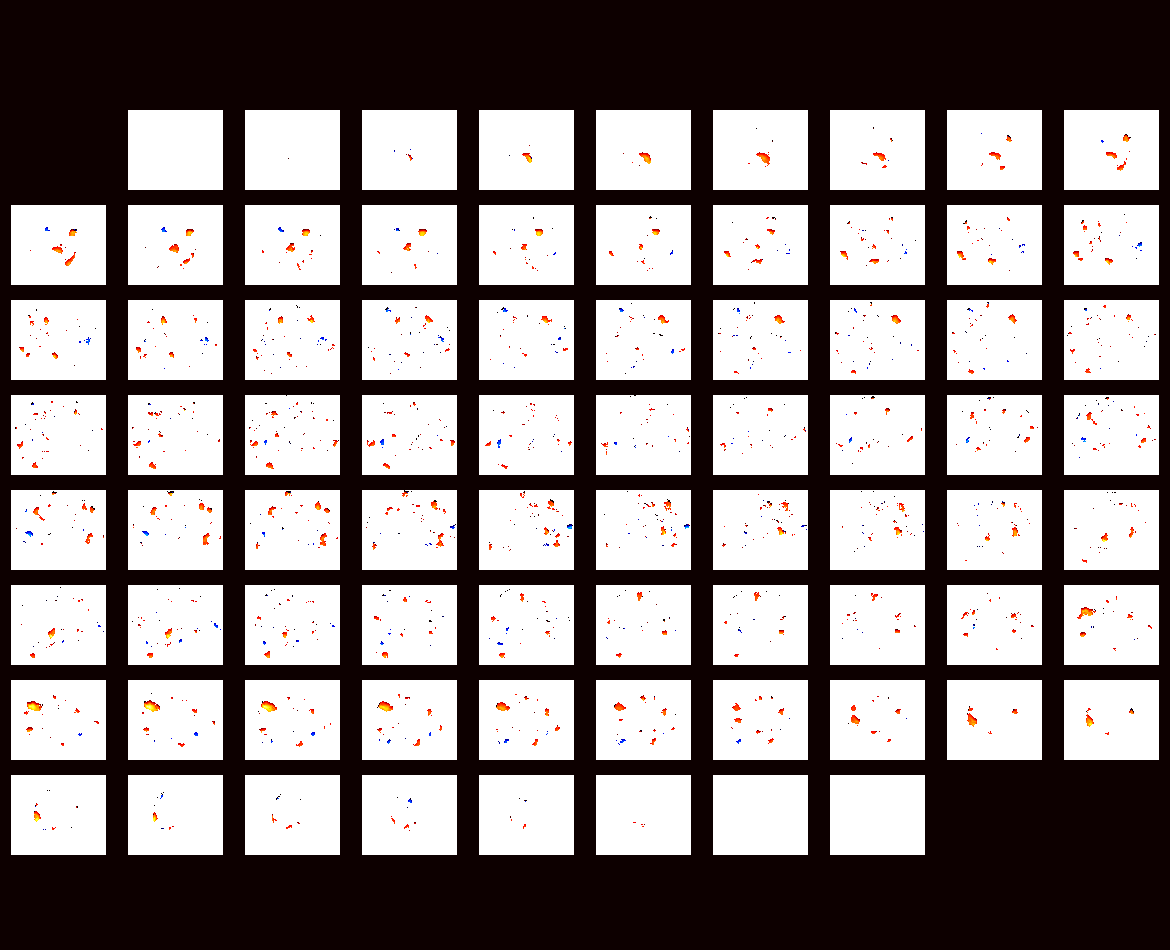

In [52]:
plotting.view_img(z_map, #thresholded_map,
                  threshold=1.7,
                  symmetric_cmap=True,
                  title=f'{group_label} {model_label} RSA')

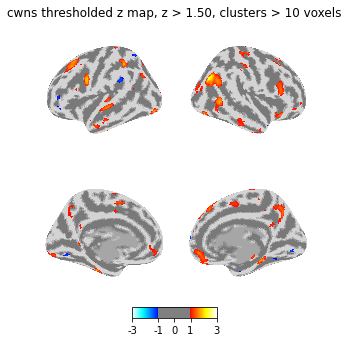

In [50]:
threshold = 1.5
plotting.plot_img_on_surf(z_map,
                          #surf_mesh='fsaverage', # comment out for faster default (fsaverage5)
                          views=['lateral', 'medial'],
                          hemispheres=['left', 'right'],
                          inflate=True,
                          threshold=threshold,
                          #cmap='Reds',
                          colorbar=True,
                          title='%s thresholded z map, z > %.02f, clusters > %d voxels'%(group_label, threshold, cthresh))
plotting.show()

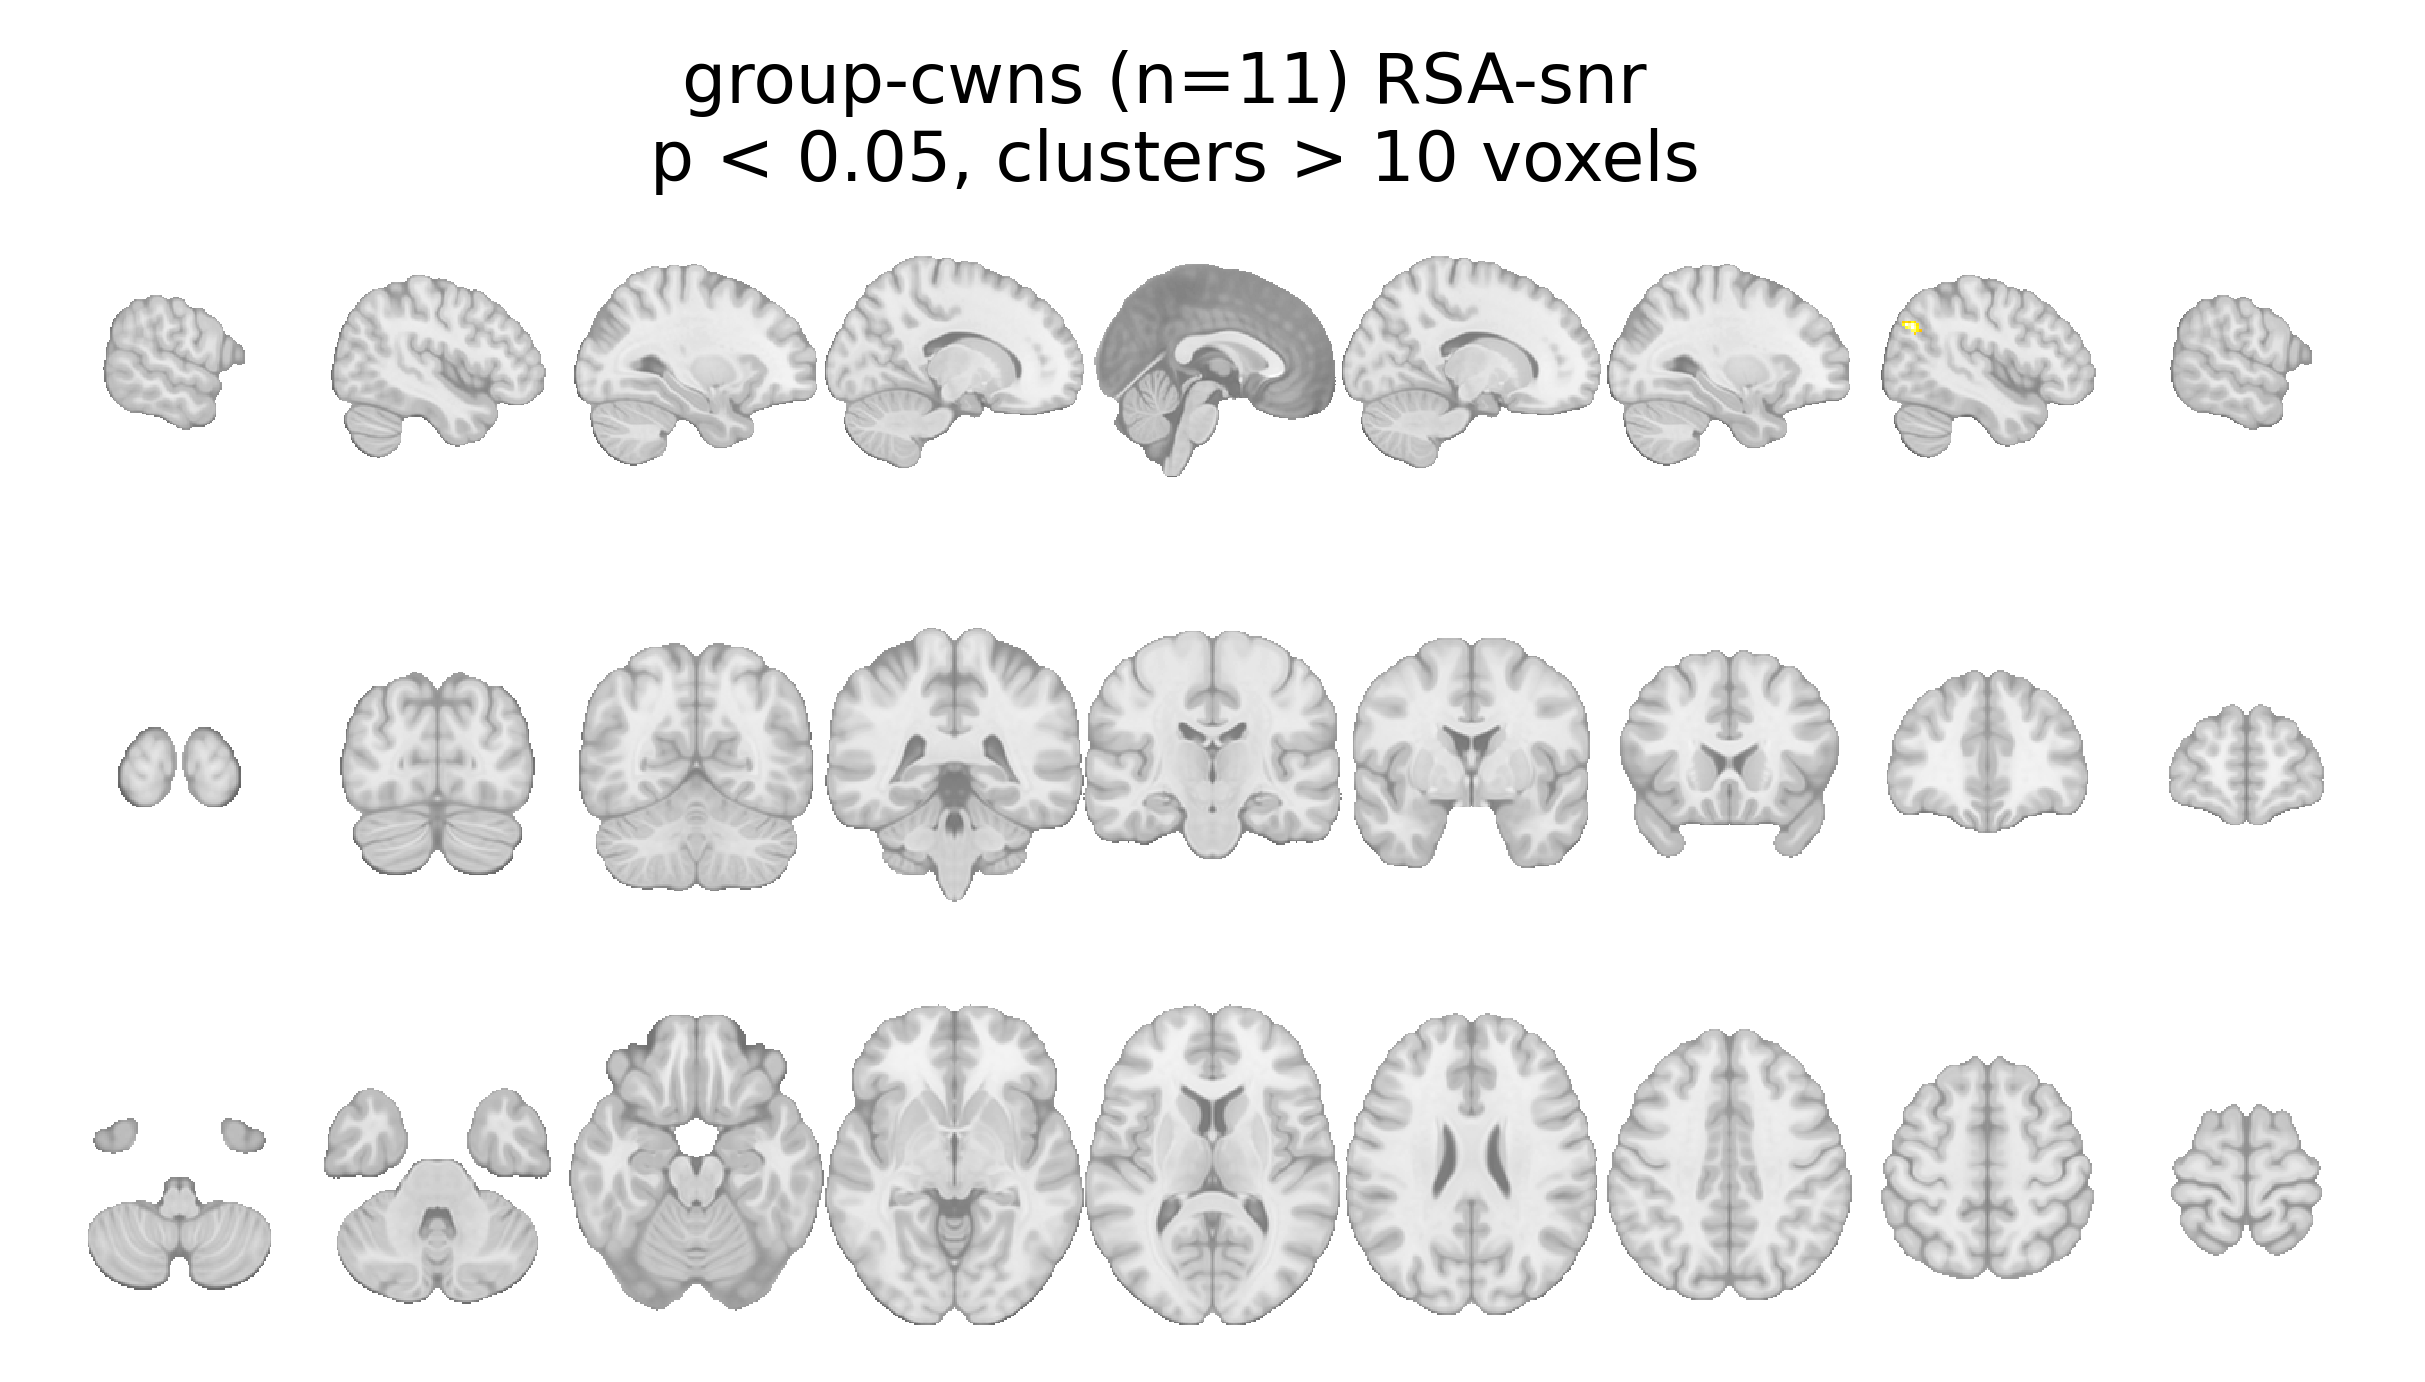

In [56]:
title = (f'group-{group_label} (n=%d) RSA-%s \n'
              'p < %.02f, clusters > %d voxels'%(len(sub_list_cwns), model_label, alpha, cthresh))

#fig = plt.figure(constrained_layout=True, figsize=(8,4), dpi=500)
#subfigs = fig.subfigures(nrows=3, ncols=1)
fig, axes = plt.subplots(3, 1, figsize=(6,3), dpi=500)
fig.suptitle(title, fontsize='medium')

fig_fpath = os.path.join(l2_dir, 
                         f'group-{group_label}_rsa-searchlight_model-{model_label}_searchrad-{searchrad}_fwhm-{fwhm}_map-zstat_slice.png')

plotting.plot_stat_map(thresholded_map, 
                       bg_img=mni152_template, 
                       black_bg=False,
                       display_mode='x',
                       cut_coords=[-60, -45, -30, -15, 0, 15, 30, 45, 60],
                       colorbar=False,
                       annotate=False,
                       #title=title,
                       figure=fig, 
                       axes=axes[0])
plotting.plot_stat_map(thresholded_map, 
                       bg_img=mni152_template, 
                       black_bg=False,
                       display_mode='y',
                       cut_coords=[-100, -80, -60, -40, -20, 0, 20, 40, 60],
                       colorbar=False,
                       annotate=False,
                       #title=title,
                       figure=fig, 
                       axes=axes[1])
plotting.plot_stat_map(thresholded_map, 
                       bg_img=mni152_template, 
                       black_bg=False,
                       display_mode='z',
                       cut_coords=[-50, -35, -20, -5, 10, 25, 40, 55, 70],
                       colorbar=False,
                       annotate=False,
                       #title=title,
                       #figure=fig, 
                       axes=axes[2])

#fig.savefig(fig_fpath)
#print('file saved to ', fig_fpath)

## Syllable model

In [57]:
model_label = model_list[1]

In [58]:
run_num = 1

l1_fnames_groupdiff = [sorted(glob(l1_dir+f'/{sub_id}/run-{run_num}/' +
                                   f'{sub_id}_{run_num}_fwhm-{fwhm:.02f}_searchvox-{searchrad}_rsa-searchlight_contrast-sound_model-{model_label}.nii.gz'))[0] for sub_id in subjects_label]

In [59]:
l1_fnames_groupdiff

['/bgfs/bchandrasekaran/krs228/data/SSP/data_bids/derivatives/nilearn/rsa-searchlight_run-specific/sub-SSP009/run-1/sub-SSP009_1_fwhm-0.00_searchvox-5_rsa-searchlight_contrast-sound_model-syllable.nii.gz',
 '/bgfs/bchandrasekaran/krs228/data/SSP/data_bids/derivatives/nilearn/rsa-searchlight_run-specific/sub-SSP011/run-1/sub-SSP011_1_fwhm-0.00_searchvox-5_rsa-searchlight_contrast-sound_model-syllable.nii.gz',
 '/bgfs/bchandrasekaran/krs228/data/SSP/data_bids/derivatives/nilearn/rsa-searchlight_run-specific/sub-SSP017/run-1/sub-SSP017_1_fwhm-0.00_searchvox-5_rsa-searchlight_contrast-sound_model-syllable.nii.gz',
 '/bgfs/bchandrasekaran/krs228/data/SSP/data_bids/derivatives/nilearn/rsa-searchlight_run-specific/sub-SSP018/run-1/sub-SSP018_1_fwhm-0.00_searchvox-5_rsa-searchlight_contrast-sound_model-syllable.nii.gz',
 '/bgfs/bchandrasekaran/krs228/data/SSP/data_bids/derivatives/nilearn/rsa-searchlight_run-specific/sub-SSP020/run-1/sub-SSP020_1_fwhm-0.00_searchvox-5_rsa-searchlight_contrast-

### loop through images and transform fisher's r-to-z

In [60]:
diff_img_list = []

for sx, sub_sl_fpath in enumerate(l1_fnames_groupdiff):
    
    sub_sl_img = nib.load(sub_sl_fpath)
    sub_sl_data = sub_sl_img.get_fdata()

    # fisher transform r-to-z
    diff_data = np.arctanh(sub_sl_data)

    diff_img = new_img_like(sub_sl_img, diff_data)

    diff_img_list.append(diff_img)

### CWNS group RSA

In [61]:
#second_level_model = SecondLevelModel().fit(smoothed_l1_fnames_groupdiff, design_matrix=design_mat_groupdiff)
second_level_model = SecondLevelModel().fit(diff_img_list, design_matrix=design_mat_groupdiff)

z_map = second_level_model.compute_contrast(second_level_contrast=[0, 1,], output_type='z_score')

In [62]:
group_label = 'cwns'
out_fname = f'group-{group_label}_model-{model_label}_map-zstat.nii.gz'
out_fpath = os.path.join(l2_dir, out_fname)
nib.save(z_map, out_fpath)

In [63]:
print(out_fpath)

/bgfs/bchandrasekaran/krs228/data/SSP/data_bids/derivatives/nilearn/group_rsa-searchlight_run-specific/group-cwns_model-syllable_map-zstat.nii.gz


In [64]:
from nilearn.image import threshold_img
from nilearn.glm import threshold_stats_img
alpha = 0.05
cthresh = 10
cluster_correct = None # 'fdr'

thresholded_map, zthresh = threshold_stats_img(
                            z_map,
                            alpha=alpha,
                            height_control=cluster_correct,
                            cluster_threshold=cthresh,
                            two_sided=True,
                        )

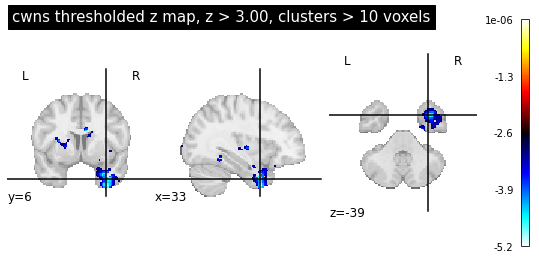

In [65]:
plotting.plot_stat_map(
    thresholded_map, #cut_coords=[17,12,5], 
    #threshold=threshold,
    title='%s thresholded z map, z > %.02f, clusters > %d voxels'%(group_label, zthresh, cthresh))

/bgfs/bchandrasekaran/krs228/software/miniconda3/envs/py3/lib/python3.9/site-packages/numpy/core/fromnumeric.py:758: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  a.partition(kth, axis=axis, kind=kind, order=order)



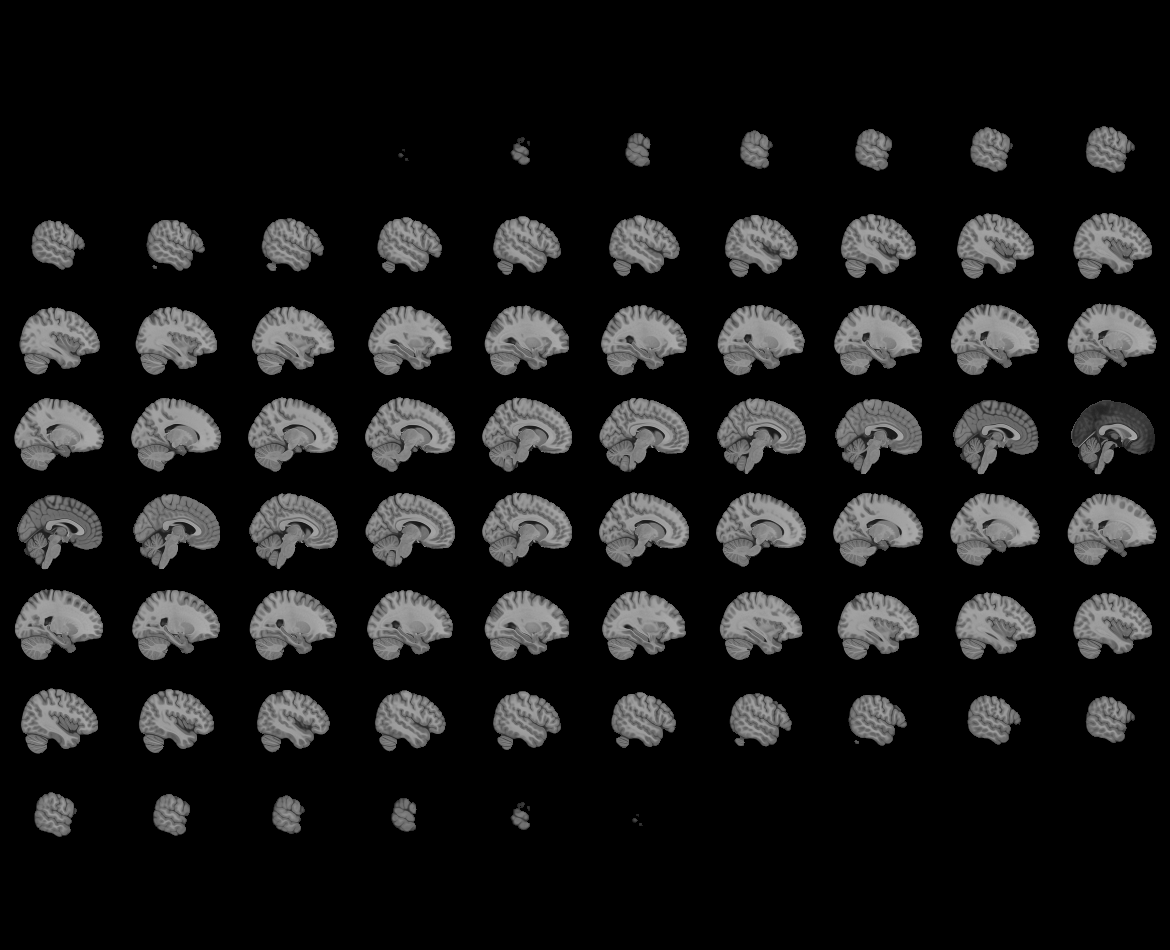
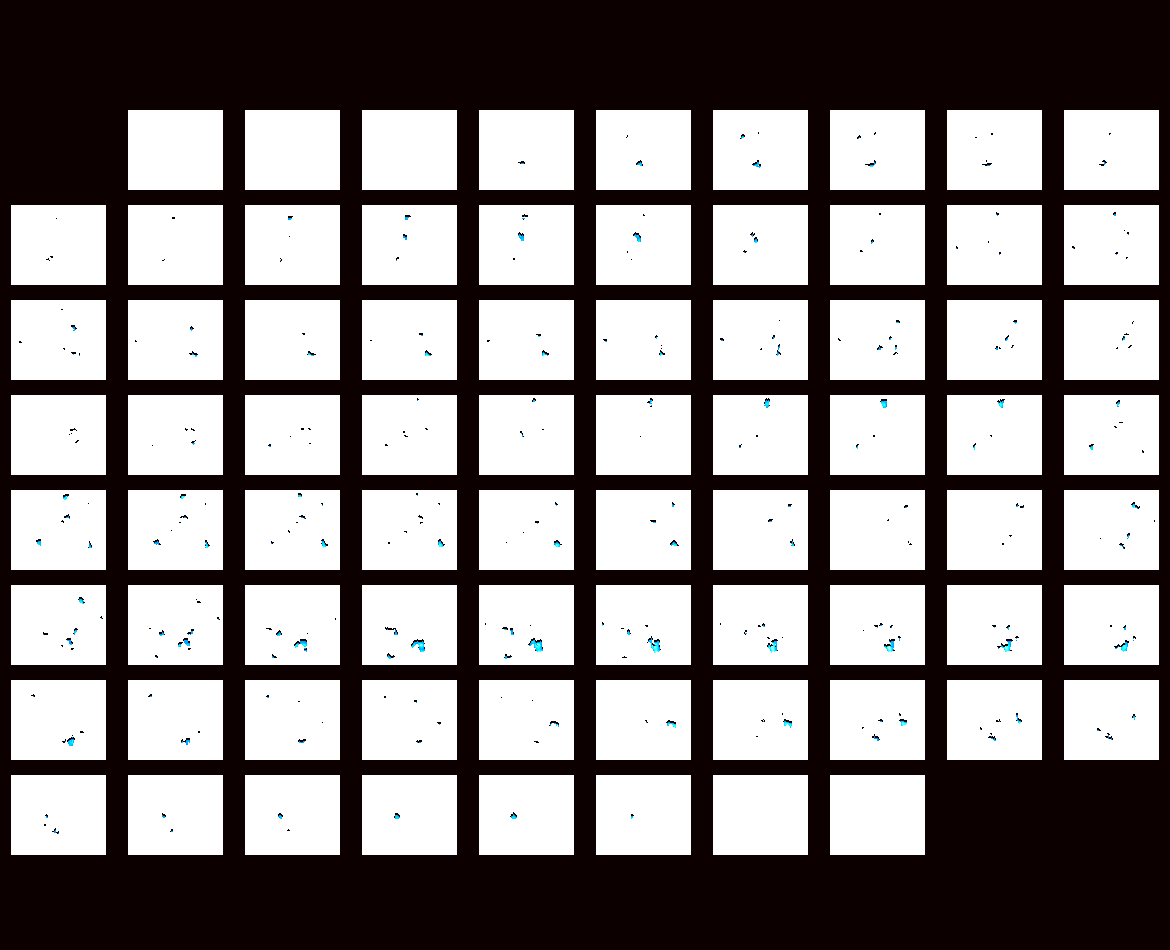

In [69]:
plotting.view_img(thresholded_map, # z_map,
                  threshold=1.7,
                  symmetric_cmap=True,
                  title=f'{group_label} {model_label} RSA')

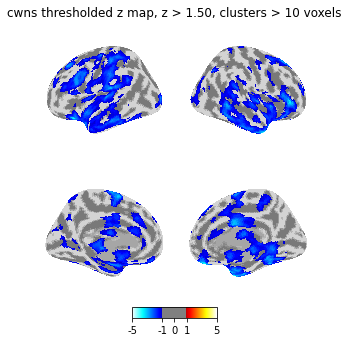

In [67]:
threshold = 1.5
plotting.plot_img_on_surf(z_map,
                          #surf_mesh='fsaverage', # comment out for faster default (fsaverage5)
                          views=['lateral', 'medial'],
                          hemispheres=['left', 'right'],
                          inflate=True,
                          threshold=threshold,
                          #cmap='Reds',
                          colorbar=True,
                          title='%s thresholded z map, z > %.02f, clusters > %d voxels'%(group_label, threshold, cthresh))
plotting.show()

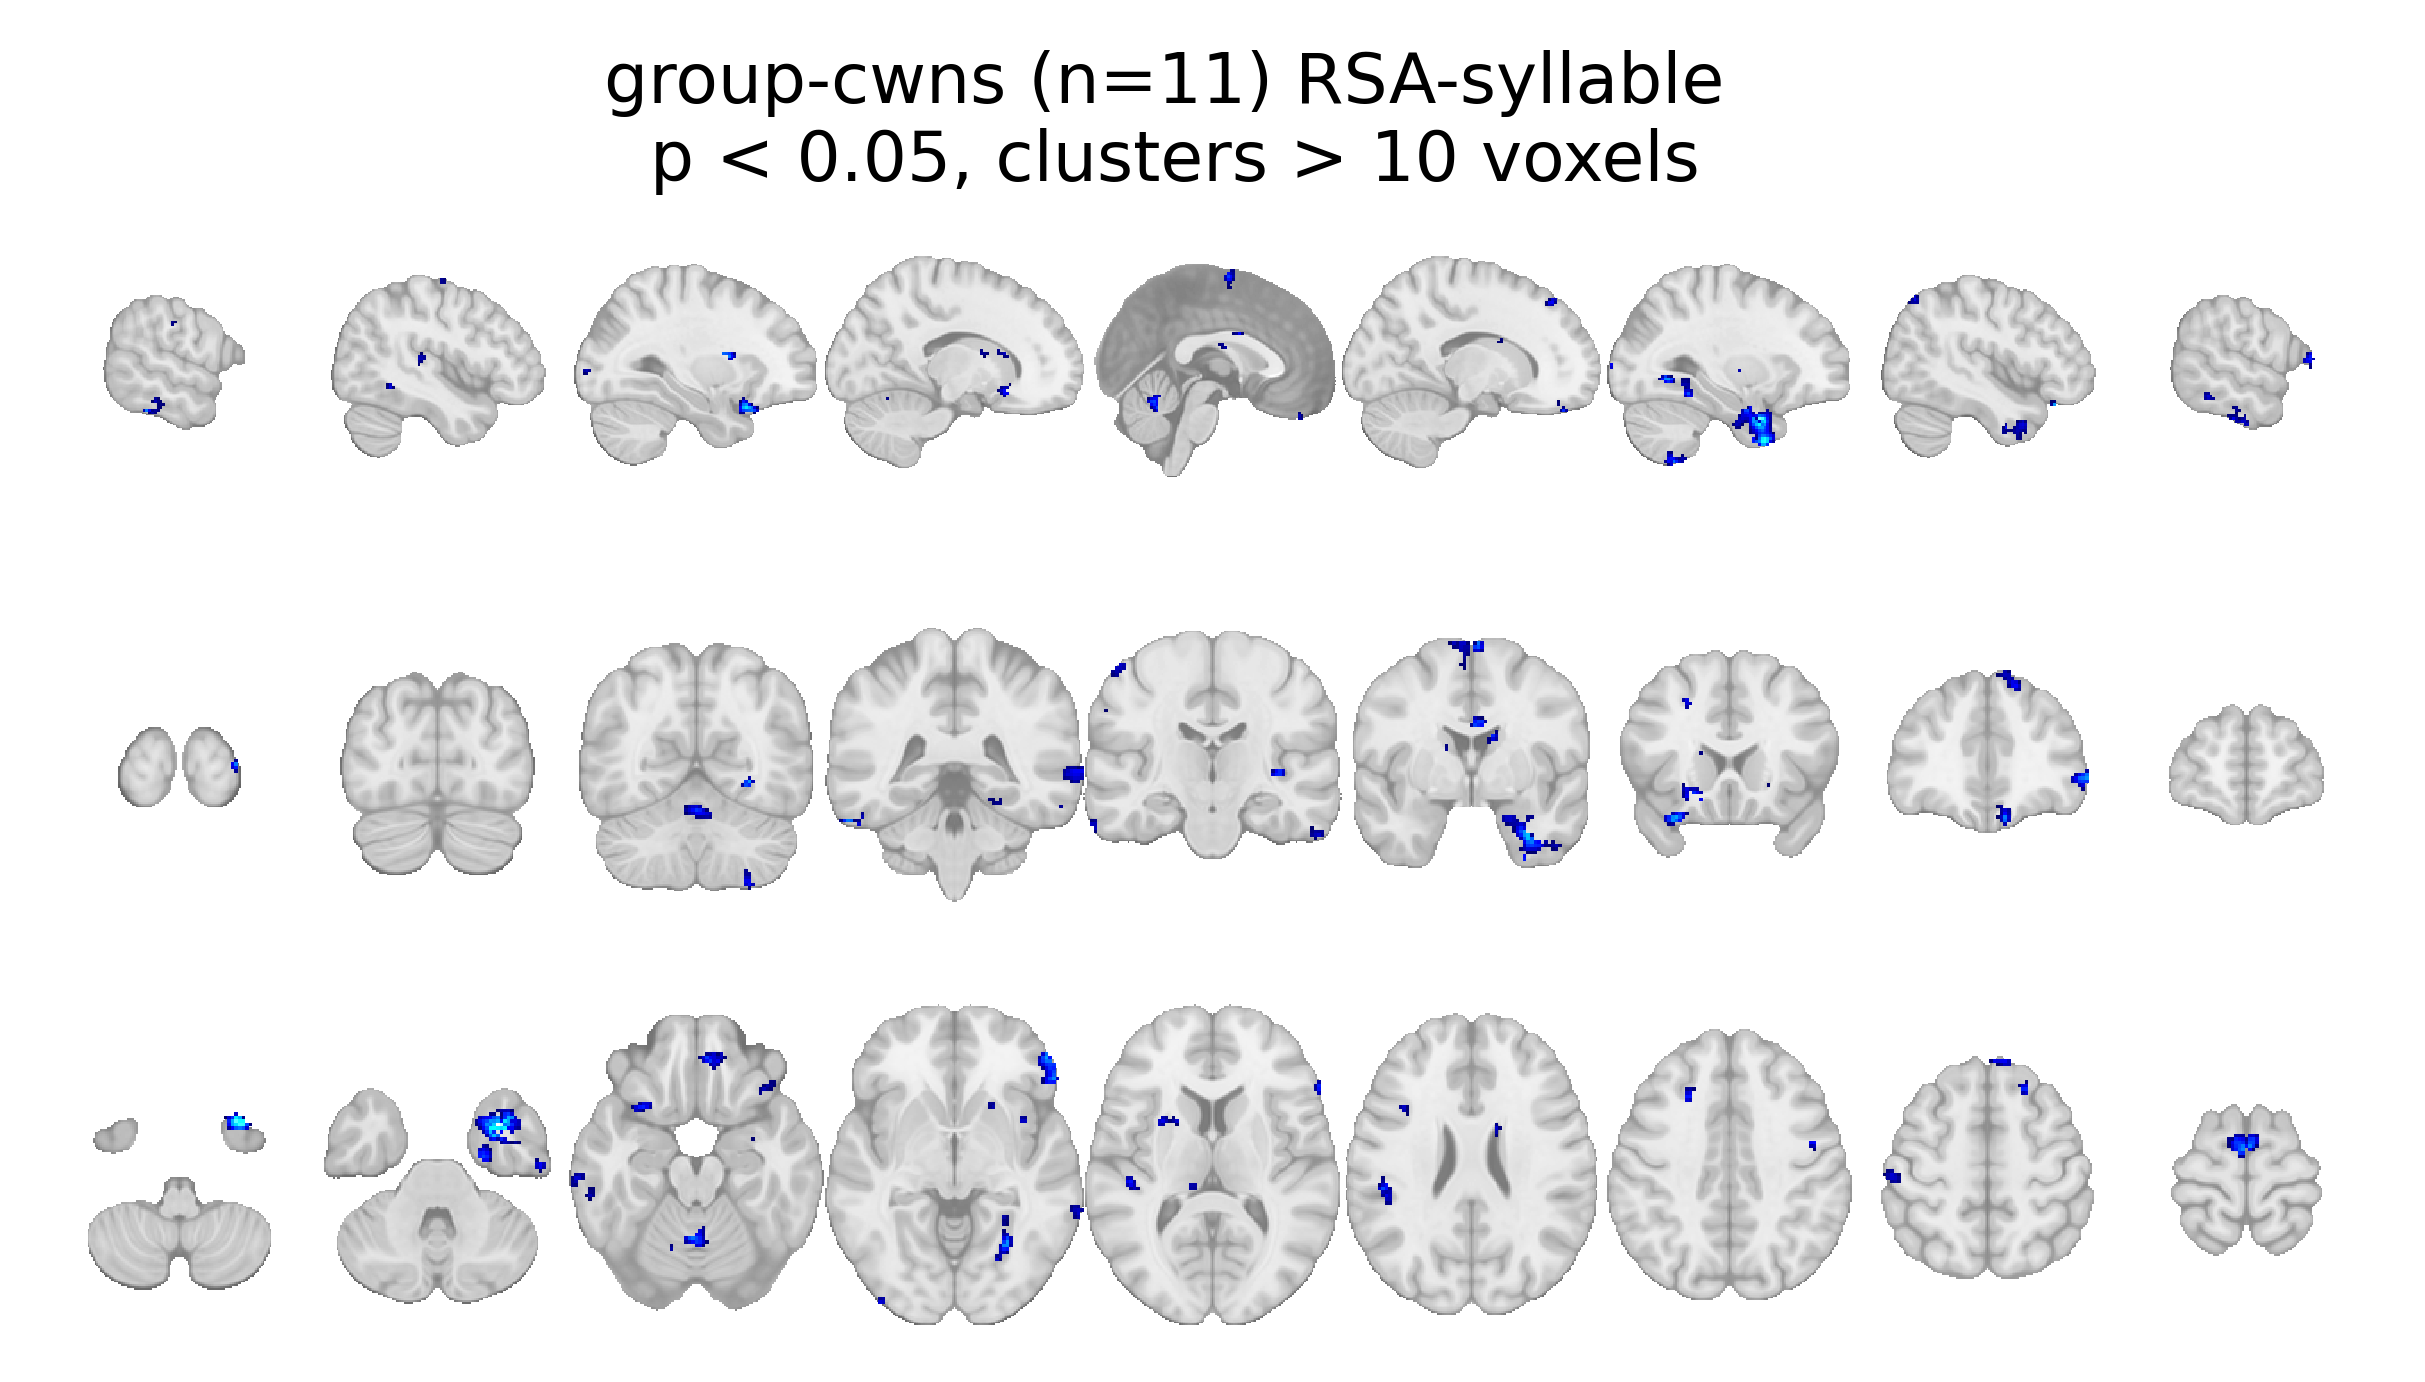

In [68]:
title = (f'group-{group_label} (n=%d) RSA-%s \n'
              'p < %.02f, clusters > %d voxels'%(len(sub_list_cwns), model_label, alpha, cthresh))

#fig = plt.figure(constrained_layout=True, figsize=(8,4), dpi=500)
#subfigs = fig.subfigures(nrows=3, ncols=1)
fig, axes = plt.subplots(3, 1, figsize=(6,3), dpi=500)
fig.suptitle(title, fontsize='medium')

fig_fpath = os.path.join(l2_dir, 
                         f'group-{group_label}_rsa-searchlight_model-{model_label}_searchrad-{searchrad}_fwhm-{fwhm}_map-zstat_slice.png')

plotting.plot_stat_map(thresholded_map, 
                       bg_img=mni152_template, 
                       black_bg=False,
                       display_mode='x',
                       cut_coords=[-60, -45, -30, -15, 0, 15, 30, 45, 60],
                       colorbar=False,
                       annotate=False,
                       #title=title,
                       figure=fig, 
                       axes=axes[0])
plotting.plot_stat_map(thresholded_map, 
                       bg_img=mni152_template, 
                       black_bg=False,
                       display_mode='y',
                       cut_coords=[-100, -80, -60, -40, -20, 0, 20, 40, 60],
                       colorbar=False,
                       annotate=False,
                       #title=title,
                       figure=fig, 
                       axes=axes[1])
plotting.plot_stat_map(thresholded_map, 
                       bg_img=mni152_template, 
                       black_bg=False,
                       display_mode='z',
                       cut_coords=[-50, -35, -20, -5, 10, 25, 40, 55, 70],
                       colorbar=False,
                       annotate=False,
                       #title=title,
                       #figure=fig, 
                       axes=axes[2])

#fig.savefig(fig_fpath)
#print('file saved to ', fig_fpath)